In [2]:
import pandas as pd

# Load Data

NOTE - Some cleaning was required to account for Facebook's rebranded to Meta. Can copy that code over here if needed. For now, I am loading the dataset with this problem fixed.

### Daily Data

In [2]:
import pandas as pd
df_daily_data = pd.read_csv('transformed_daily_data/Cleaned_New_2026_05_18.csv')
df_daily_data = df_daily_data.sort_values(by=['ticker', 'timestamp'])
df_daily_data

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-05,A,132.09,134.090,131.2500,133.370,1.447574e+06,133.1998,19877.0
1,2021-05-06,A,132.31,132.600,130.7700,132.400,1.173755e+06,131.8933,20455.0
2,2021-05-07,A,133.19,134.820,133.1900,133.900,1.056246e+06,133.9869,17352.0
3,2021-05-10,A,133.76,133.930,131.7600,131.870,1.048008e+06,132.4934,22316.0
4,2021-05-11,A,130.27,131.840,129.3000,131.420,1.356117e+06,131.1175,19161.0
...,...,...,...,...,...,...,...,...,...
4986892,2026-04-27,NaN,2.29,2.290,1.8500,1.850,9.317473e+04,2.1023,1094.0
4986893,2026-04-28,NaN,2.01,2.110,1.7800,1.795,2.693652e+05,1.9115,1846.0
4986894,2026-04-29,NaN,1.86,1.860,1.6000,1.605,1.364121e+05,1.6963,1155.0
4986895,2026-04-30,NaN,1.60,1.850,1.5801,1.770,1.013014e+05,1.6733,858.0


In [3]:
df_daily_data['ticker'].value_counts()

ticker
A       1254
MFA     1254
MEC     1254
MED     1254
MEDP    1254
        ... 
QXL        2
DYNC       1
COAG       1
UCFI       1
SPTX       1
Name: count, Length: 5037, dtype: int64

Filtering

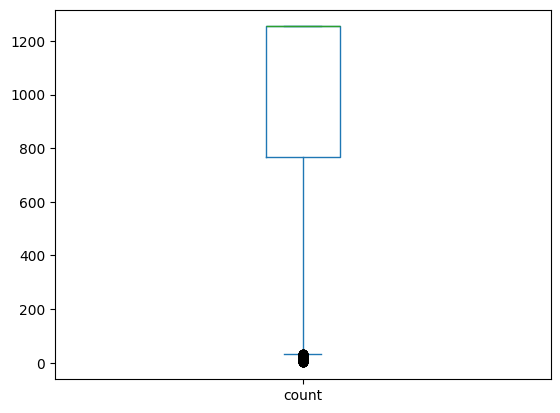

In [4]:
import matplotlib.pyplot as plt

df_daily_data['ticker'].value_counts().plot.box()

plt.show()

In [5]:
thresholds = [1200, 1220, 1229, 1230, 1240, 1250, 1253, 1254]

ticker_counts = df_daily_data['ticker'].value_counts()

for t in thresholds:
    count = (ticker_counts >= t).sum()
    print(f">={t}: {count}")

>=1200: 3145
>=1220: 3068
>=1229: 3033
>=1230: 3025
>=1240: 2985
>=1250: 2924
>=1253: 2870
>=1254: 2804


My original methodology for filling missing days was to find stocks in which no more than 2% of days were missing, AND there were no consecutive missing days, AND none of the missing days were on Monday or Friday. Any remaining missing days would then be forward-filled with the previous day.

This was feasible with a volume filter applied, but since there is none right now, this would be time prohibitive. Therefore, I will tolerate zero missing days. May change this later.

For transformation, we'll make a copy.

In [6]:
df_cleaned_daily = df_daily_data.copy()

In [7]:
import pandas as pd

ticker_counts = df_cleaned_daily.set_index('timestamp')['ticker'].value_counts()

mask = df_cleaned_daily['ticker'].isin(ticker_counts[ticker_counts >= 1254].index)

df_cleaned_daily = df_cleaned_daily[mask]

df_cleaned_daily

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-05,A,132.090,134.090,131.25,133.37,1.447574e+06,133.1998,19877.0
1,2021-05-06,A,132.310,132.600,130.77,132.40,1.173755e+06,131.8933,20455.0
2,2021-05-07,A,133.190,134.820,133.19,133.90,1.056246e+06,133.9869,17352.0
3,2021-05-10,A,133.760,133.930,131.76,131.87,1.048008e+06,132.4934,22316.0
4,2021-05-11,A,130.270,131.840,129.30,131.42,1.356117e+06,131.1175,19161.0
...,...,...,...,...,...,...,...,...,...
4985939,2026-04-27,ZYME,27.930,29.750,27.93,28.56,9.502180e+05,28.8344,13412.0
4985940,2026-04-28,ZYME,28.610,28.885,27.92,27.94,4.214716e+05,28.1324,9773.0
4985941,2026-04-29,ZYME,27.520,27.950,26.77,27.83,8.244088e+05,27.7028,13249.0
4985942,2026-04-30,ZYME,27.975,28.185,27.18,27.54,4.826677e+05,27.5929,11679.0


In [8]:
df_cleaned_daily['ticker'].value_counts()

ticker
A       1254
ONCY    1254
OM      1254
OMC     1254
OMCL    1254
        ... 
FATE    1254
FBIO    1254
FBIZ    1254
FBK     1254
ZYME    1254
Name: count, Length: 2804, dtype: int64

Add moving averages - A later question asks for this, so add it now.

In [9]:
df_cleaned_daily['SMA10'] = df_cleaned_daily.groupby('ticker')['close'].transform(lambda x: x.rolling(10).mean())
df_cleaned_daily['SMA20'] = df_cleaned_daily.groupby('ticker')['close'].transform(lambda x: x.rolling(20).mean())
df_cleaned_daily['SMA50'] = df_cleaned_daily.groupby('ticker')['close'].transform(lambda x: x.rolling(50).mean())
df_cleaned_daily['SMA100'] = df_cleaned_daily.groupby('ticker')['close'].transform(lambda x: x.rolling(100).mean())

Add next day and previous day stats here.

In [10]:
df_cleaned_daily['pct_change_from_prev'] = (
    df_cleaned_daily.groupby('ticker')['close']
    .pct_change() * 100
)

df_cleaned_daily['next_close_pct_change'] = (
    (
        df_cleaned_daily.groupby('ticker')['close']
        .shift(-1)
        / df_cleaned_daily['close']
    - 1
    ) * 100
)

In [11]:
df_cleaned_daily

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,SMA10,SMA20,SMA50,SMA100,pct_change_from_prev,next_close_pct_change
0,2021-05-05,A,132.090,134.090,131.25,133.37,1.447574e+06,133.1998,19877.0,NaN,NaN,NaN,NaN,NaN,-0.727300
1,2021-05-06,A,132.310,132.600,130.77,132.40,1.173755e+06,131.8933,20455.0,NaN,NaN,NaN,NaN,-0.727300,1.132931
2,2021-05-07,A,133.190,134.820,133.19,133.90,1.056246e+06,133.9869,17352.0,NaN,NaN,NaN,NaN,1.132931,-1.516057
3,2021-05-10,A,133.760,133.930,131.76,131.87,1.048008e+06,132.4934,22316.0,NaN,NaN,NaN,NaN,-1.516057,-0.341245
4,2021-05-11,A,130.270,131.840,129.30,131.42,1.356117e+06,131.1175,19161.0,NaN,NaN,NaN,NaN,-0.341245,-2.115355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4985939,2026-04-27,ZYME,27.930,29.750,27.93,28.56,9.502180e+05,28.8344,13412.0,27.845,26.8915,25.0433,24.8368,1.637011,-2.170868
4985940,2026-04-28,ZYME,28.610,28.885,27.92,27.94,4.214716e+05,28.1324,9773.0,27.941,27.0780,25.1501,24.8652,-2.170868,-0.393701
4985941,2026-04-29,ZYME,27.520,27.950,26.77,27.83,8.244088e+05,27.7028,13249.0,27.951,27.2175,25.2453,24.8813,-0.393701,-1.042041
4985942,2026-04-30,ZYME,27.975,28.185,27.18,27.54,4.826677e+05,27.5929,11679.0,27.985,27.2975,25.3379,24.8915,-1.042041,-3.376906


In [12]:
df_cleaned_daily = df_cleaned_daily.dropna()

In [13]:
df_cleaned_daily

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,SMA10,SMA20,SMA50,SMA100,pct_change_from_prev,next_close_pct_change
99,2021-09-24,A,172.090,173.080,171.2000,172.40,1.041912e+06,172.4244,15834.0,172.590,174.7785,164.3732,152.4526,-0.214158,-3.491879
100,2021-09-27,A,171.060,171.150,164.2629,166.38,1.419754e+06,166.1472,25590.0,172.020,174.4070,164.7222,152.7827,-3.491879,-3.894699
101,2021-09-28,A,164.190,164.330,158.7900,159.90,2.541015e+06,160.4667,41170.0,170.768,173.5655,164.9686,153.0577,-3.894699,0.062539
102,2021-09-29,A,161.390,161.805,159.8300,160.00,1.268214e+06,160.5194,22512.0,169.389,172.7920,165.1826,153.3187,0.062539,-1.543750
103,2021-09-30,A,161.230,162.480,157.4600,157.53,1.558941e+06,158.5686,21666.0,167.814,171.8960,165.3542,153.5753,-1.543750,-0.977592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4985938,2026-04-24,ZYME,27.510,28.300,26.9300,28.10,5.705914e+05,27.9745,11600.0,27.606,26.6725,24.9355,24.8115,2.442581,1.637011
4985939,2026-04-27,ZYME,27.930,29.750,27.9300,28.56,9.502180e+05,28.8344,13412.0,27.845,26.8915,25.0433,24.8368,1.637011,-2.170868
4985940,2026-04-28,ZYME,28.610,28.885,27.9200,27.94,4.214716e+05,28.1324,9773.0,27.941,27.0780,25.1501,24.8652,-2.170868,-0.393701
4985941,2026-04-29,ZYME,27.520,27.950,26.7700,27.83,8.244088e+05,27.7028,13249.0,27.951,27.2175,25.2453,24.8813,-0.393701,-1.042041


In [14]:
df_daily_five_years = df_cleaned_daily.copy()

In [15]:
df_daily_two_years = df_daily_five_years[df_daily_five_years['timestamp'] >= '2024-04-30']

In [74]:
df_daily_one_year = df_daily_five_years[df_daily_five_years['timestamp'] >= '2025-04-30']

My raw daily dataset ran from 2021/05/05 to 2026/05/01.

When SMAs are applied up to 100 days, the first 99 days will be null as there are insufficient days to calculate SMA100, and consequently will have to be dropped.

Similarly, if next_day metrics are calculated, the final day will have to be dropped as there will be no next day.

With both of these changes, the new span will be 2021/07/15 to 2026/04/30.

### Hourly Data

In [13]:
df_hourly_data

NameError: name 'df_hourly_data' is not defined

# LOAD LIVE DATA?

# EDA TASKS

# 2. Plot long-term stock data over multiple years.
Create an interactive graph that allows the user to view different time ranges.

This should probably be a Streamlit app then?

# 3. Start with Apple (AAPL) and plot its stock chart using daily data over several years.

In [16]:
daily_aapl_five_years = df_daily_five_years[df_daily_five_years['ticker'] == 'AAPL']
daily_amzn_five_years = df_daily_five_years[df_daily_five_years['ticker'] == 'AMZN']
daily_meta_five_years = df_daily_five_years[df_daily_five_years['ticker'] == 'META']
daily_nflx_five_years = df_daily_five_years[df_daily_five_years['ticker'] == 'NFLX']
daily_nvda_five_years = df_daily_five_years[df_daily_five_years['ticker'] == 'NVDA']
daily_googl_five_years = df_daily_five_years[df_daily_five_years['ticker'] == 'GOOGL']

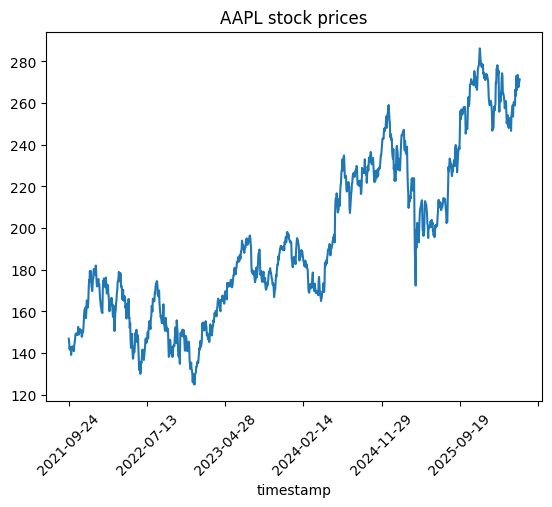

In [17]:
import matplotlib.pyplot as plt

daily_aapl_five_years = df_daily_five_years[df_daily_five_years['ticker'] == 'AAPL']

daily_aapl_five_years.set_index('timestamp')['close'].plot()
plt.xticks(rotation=45)
# This title will have to be changed if SMA and next_close stats result in rows being dropped
plt.title('AAPL stock prices')
plt.show()

# 4. Add moving averages to the stock charts, such as:
○ SMA20 and SMA50, or
○ SMA50 and SMA150
These should be overlaid on the main stock price chart.

These metrics were created at an earlier stage.

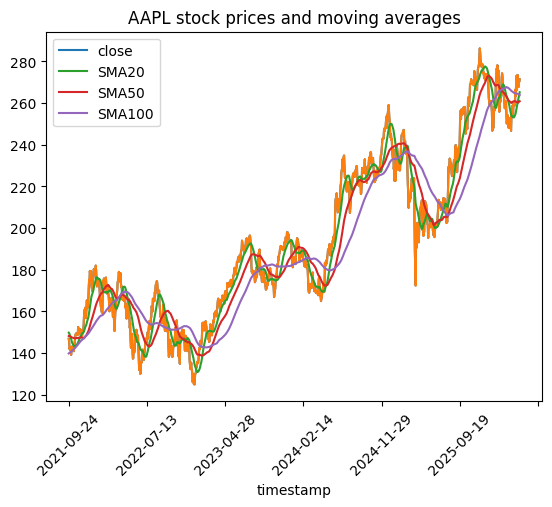

In [21]:
daily_aapl_five_years.set_index('timestamp')['close'].plot()


plt.plot(daily_aapl_five_years['timestamp'], daily_aapl_five_years['close'])
plt.plot(daily_aapl_five_years['timestamp'], daily_aapl_five_years['SMA20'], label='SMA20')
plt.plot(daily_aapl_five_years['timestamp'], daily_aapl_five_years['SMA50'], label='SMA50')
plt.plot(daily_aapl_five_years['timestamp'], daily_aapl_five_years['SMA100'], label='SMA100')
plt.xticks(rotation=45)
# This title will have to be changed if SMA and next_close stats result in rows being dropped
plt.title('AAPL stock prices and moving averages')
plt.legend()
plt.show()

5. Create a table for five stocks. Use default examples such as FAANG stocks plus
NVIDIA, but allow the user to change them.

For each stock, calculate the historical probability that the next day is positive if the
current day changes by:
+2%, +3%, +4%, +5%, and +6%.
Example: if Apple rises 5% today, what is the historical probability that the next day
closes positive?
Use the last 2 years of historical data.

I'll make the default here for now.

Will have to make a dataframe in the cleaning stage, showing by stock these probabilites, one for each column.

User changeability will be added to the Streamlit when I reach that point.

In [156]:
prev_change_condition = (daily_aapl_two_years['pct_change_from_prev'] >=2)
next_change_condition = (daily_aapl_two_years['next_close_pct_change'] >=0)
full_condition = prev_change_condition & next_change_condition

matching_days = full_condition.sum()
total_prev_days = prev_change_condition.sum()

full_condition_pct = matching_days / total_prev_days
full_condition_pct

np.float64(0.6904761904761905)

Now adapt this with variables.

AAPL alone

In [25]:
daily_aapl_two_years = df_daily_two_years[df_daily_two_years['ticker'] == 'AAPL']

thresholds = 2, 3, 4, 5, 6

for threshold in thresholds:
    prev_change_condition = (daily_aapl_two_years['pct_change_from_prev'] >= threshold)
    next_change_condition = (daily_aapl_two_years['next_close_pct_change'] >=0)
    full_condition = prev_change_condition & next_change_condition
    
    matching_days = full_condition.sum()
    total_prev_days = prev_change_condition.sum()
    
    full_condition_pct = matching_days / total_prev_days
    
    print(f"Probability of a positive change the day after a {threshold}% increase: {full_condition_pct:.3f}")
    #full_condition_pct

Probability of a positive change the day after a 2% increase: 0.690
Probability of a positive change the day after a 3% increase: 0.667
Probability of a positive change the day after a 4% increase: 0.444
Probability of a positive change the day after a 5% increase: 0.600
Probability of a positive change the day after a 6% increase: 0.667


Wrote this nested for loop myself, calculating logic somewhat incorrect.

In [22]:
#ticker_list = df_daily_five_years['ticker'].unique().tolist()
ticker_list = ['AAPL', 'GOOGL']

thresholds = 2, 3, 4, 5, 6

for ticker in ticker_list:
    for threshold in thresholds:
        prev_change_condition = (df_daily_five_years['pct_change_from_prev'] >= threshold)
        next_change_condition = (df_daily_five_years['next_close_pct_change'] >=0)
        full_condition = prev_change_condition & next_change_condition
        
        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()
        
        full_condition_pct = matching_days / total_prev_days
        
        print(f"{ticker}: Probability of a positive change the day after a {threshold}% increase: {full_condition_pct:.3f}")


AAPL: Probability of a positive change the day after a 2% increase: 0.488
AAPL: Probability of a positive change the day after a 3% increase: 0.486
AAPL: Probability of a positive change the day after a 4% increase: 0.483
AAPL: Probability of a positive change the day after a 5% increase: 0.481
AAPL: Probability of a positive change the day after a 6% increase: 0.478
GOOGL: Probability of a positive change the day after a 2% increase: 0.488
GOOGL: Probability of a positive change the day after a 3% increase: 0.486
GOOGL: Probability of a positive change the day after a 4% increase: 0.483
GOOGL: Probability of a positive change the day after a 5% increase: 0.481
GOOGL: Probability of a positive change the day after a 6% increase: 0.478


Below adapted to correct calculation logic.

In [69]:
#ticker_list = df_daily_two_years['ticker'].unique().tolist()
ticker_list = ['AAPL', 'NVDA', 'NFLX', 'AMZN', 'GOOGL', 'META']

thresholds = 2, 3, 4, 5, 6, 10, 20

print("Span: 2 years")

for ticker in ticker_list:
    ticker_df = df_daily_two_years[df_daily_two_years['ticker'] == ticker]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] >= threshold
        next_change_condition = ticker_df['next_close_pct_change'] >= 0

        full_condition = prev_change_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(f"{ticker}: Probability of a positive change the day after a {threshold}% increase: {full_condition_pct:.3f}")
        else:
            print(f"{ticker}: >>>> No days with a {threshold}% increase <<<<")

Span: 2 years
AAPL: Probability of a positive change the day after a 2% increase: 69.048
AAPL: Probability of a positive change the day after a 3% increase: 66.667
AAPL: Probability of a positive change the day after a 4% increase: 44.444
AAPL: Probability of a positive change the day after a 5% increase: 60.000
AAPL: Probability of a positive change the day after a 6% increase: 66.667
AAPL: Probability of a positive change the day after a 10% increase: 0.000
AAPL: >>>> No days with a 20% increase <<<<
NVDA: Probability of a positive change the day after a 2% increase: 53.782
NVDA: Probability of a positive change the day after a 3% increase: 50.649
NVDA: Probability of a positive change the day after a 4% increase: 52.632
NVDA: Probability of a positive change the day after a 5% increase: 55.556
NVDA: Probability of a positive change the day after a 6% increase: 54.545
NVDA: Probability of a positive change the day after a 10% increase: 0.000
NVDA: >>>> No days with a 20% increase <<<

Would also like to be able to save the results to a DataFrame.

Extra thing, from when I misinterpreted directions.

# 6. Repeat the same analysis for negative daily moves, such as:
-2%, -3%, -4%, and -5%.

In [71]:
#ticker_list = df_daily_two_years['ticker'].unique().tolist()
ticker_list = ['AAPL', 'NVDA', 'NFLX', 'AMZN', 'GOOGL', 'META']

thresholds = -1, -2, -3, -4, -5, -6, -10, -15, -20

print("Span: 2 years")

for ticker in ticker_list:
    ticker_df = df_daily_two_years[df_daily_two_years['ticker'] == ticker]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] <= threshold
        next_change_condition = ticker_df['next_close_pct_change'] < 0

        full_condition = prev_change_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(f"{ticker}: Probability of a negative change the day after a {threshold}% decrease: {full_condition_pct:.3f}")
        else:
            print(f"{ticker}: >>>> No days with a {threshold}% decrease <<<<")

Span: 2 years
AAPL: Probability of a negative change the day after a -1% decrease: 45.745
AAPL: Probability of a negative change the day after a -2% decrease: 40.909
AAPL: Probability of a negative change the day after a -3% decrease: 40.000
AAPL: Probability of a negative change the day after a -4% decrease: 62.500
AAPL: Probability of a negative change the day after a -5% decrease: 100.000
AAPL: Probability of a negative change the day after a -6% decrease: 100.000
AAPL: >>>> No days with a -10% decrease <<<<
AAPL: >>>> No days with a -15% decrease <<<<
AAPL: >>>> No days with a -20% decrease <<<<
NVDA: Probability of a negative change the day after a -1% decrease: 43.421
NVDA: Probability of a negative change the day after a -2% decrease: 40.217
NVDA: Probability of a negative change the day after a -3% decrease: 43.103
NVDA: Probability of a negative change the day after a -4% decrease: 34.286
NVDA: Probability of a negative change the day after a -5% decrease: 36.364
NVDA: Probabi

Add dataframe here?

# 7. Repeat both of the above analyses again using 5 years of historical data.

In [78]:
#ticker_list = df_daily_five_years['ticker'].unique().tolist()
ticker_list = ['AAPL', 'NVDA', 'NFLX', 'AMZN', 'GOOGL', 'META']

thresholds = 2, 3, 4, 5, 6, 10, 20

print("Span: 5 years")

for ticker in ticker_list:
    ticker_df = df_daily_five_years[df_daily_five_years['ticker'] == ticker]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] >= threshold
        next_change_condition = ticker_df['next_close_pct_change'] >= 0

        full_condition = prev_change_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(f"{ticker}: Probability of a positive change the day after a {threshold}% increase: {full_condition_pct:.3f}")
        else:
            print(f"{ticker}: >>>> No days with a {threshold}% increase <<<<")

Span: 5 years
AAPL: Probability of a positive change the day after a 2% increase: 55.172
AAPL: Probability of a positive change the day after a 3% increase: 52.273
AAPL: Probability of a positive change the day after a 4% increase: 42.105
AAPL: Probability of a positive change the day after a 5% increase: 62.500
AAPL: Probability of a positive change the day after a 6% increase: 66.667
AAPL: Probability of a positive change the day after a 10% increase: 0.000
AAPL: >>>> No days with a 20% increase <<<<
NVDA: Probability of a positive change the day after a 2% increase: 53.898
NVDA: Probability of a positive change the day after a 3% increase: 53.158
NVDA: Probability of a positive change the day after a 4% increase: 52.542
NVDA: Probability of a positive change the day after a 5% increase: 55.882
NVDA: Probability of a positive change the day after a 6% increase: 55.814
NVDA: Probability of a positive change the day after a 10% increase: 42.857
NVDA: Probability of a positive change th

In [77]:
#ticker_list = df_daily_five_years['ticker'].unique().tolist()
ticker_list = ['AAPL', 'NVDA', 'NFLX', 'AMZN', 'GOOGL', 'META']

thresholds = -1, -2, -3, -4, -5, -6, -10, -15, -20

print("Span: 5 years")

for ticker in ticker_list:
    ticker_df = df_daily_five_years[df_daily_five_years['ticker'] == ticker]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] <= threshold
        next_change_condition = ticker_df['next_close_pct_change'] < 0

        full_condition = prev_change_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(f"{ticker}: Probability of a negative change the day after a {threshold}% decrease: {full_condition_pct:.3f}")
        else:
            print(f"{ticker}: >>>> No days with a {threshold}% decrease <<<<")

Span: 5 years
AAPL: Probability of a negative change the day after a -1% decrease: 51.867
AAPL: Probability of a negative change the day after a -2% decrease: 45.455
AAPL: Probability of a negative change the day after a -3% decrease: 44.000
AAPL: Probability of a negative change the day after a -4% decrease: 64.706
AAPL: Probability of a negative change the day after a -5% decrease: 66.667
AAPL: Probability of a negative change the day after a -6% decrease: 100.000
AAPL: >>>> No days with a -10% decrease <<<<
AAPL: >>>> No days with a -15% decrease <<<<
AAPL: >>>> No days with a -20% decrease <<<<
NVDA: Probability of a negative change the day after a -1% decrease: 49.337
NVDA: Probability of a negative change the day after a -2% decrease: 45.783
NVDA: Probability of a negative change the day after a -3% decrease: 47.826
NVDA: Probability of a negative change the day after a -4% decrease: 48.421
NVDA: Probability of a negative change the day after a -5% decrease: 48.276
NVDA: Probabil

# 8. Create a comparison table for the five selected stocks.
Include a simple correlation / collinearity analysis between them.

# 9. Plot a comparison chart for two to five stocks using daily data for one year.
Example: compare Apple and Amazon.
Normalize or rescale prices if needed so they can be compared clearly.

I applied a min-max scaler to all columns, then recalculated the SMAs from there. 

I also introduced a column calculating the close as a percentage of the first day of the dataset for each ticker.

In [114]:
# Start with raw columns
rescaled_df = df_daily_five_years[['timestamp', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'vwap', 'transactions', 'pct_change_from_prev', 'next_close_pct_change']]

# Normalize
cols_to_exclude = ['timestamp', 'ticker']
normalize_cols = [col for col in rescaled_df.columns if col not in cols_to_exclude]
rescaled_df[normalize_cols] = (rescaled_df[normalize_cols] - rescaled_df[normalize_cols].min()) / (rescaled_df[normalize_cols].max() - rescaled_df[normalize_cols].min())

# Recalculate SMAs with the new normalized values
rescaled_df['SMA10'] = rescaled_df.groupby('ticker')['close'].transform(lambda x: x.rolling(10).mean())
rescaled_df['SMA20'] = rescaled_df.groupby('ticker')['close'].transform(lambda x: x.rolling(20).mean())
rescaled_df['SMA50'] = rescaled_df.groupby('ticker')['close'].transform(lambda x: x.rolling(50).mean())
rescaled_df['SMA100'] = rescaled_df.groupby('ticker')['close'].transform(lambda x: x.rolling(100).mean())

# Yearly dataframes, and changes from day one of dataset
df_five_yr_resc = rescaled_df.copy()
df_five_yr_resc['close_pct_of_day1'] = (df_five_yr_resc.groupby('ticker')['close'].transform(lambda x: (x / x.iloc[0]) * 100))


df_two_yr_resc = rescaled_df[rescaled_df['timestamp'] >= '2024-04-30']
df_two_yr_resc['close_pct_of_day1'] = (df_two_yr_resc.groupby('ticker')['close'].transform(lambda x: (x / x.iloc[0]) * 100))


df_one_yr_resc = rescaled_df[rescaled_df['timestamp'] >= '2025-04-30']
df_one_yr_resc['close_pct_of_day1'] = (df_one_yr_resc.groupby('ticker')['close'].transform(lambda x: (x / x.iloc[0]) * 100))

/var/folders/cf/4zrkk0lx1nbdx9tpklpk4jc00000gn/T/ipykernel_19087/3588216717.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rescaled_df[normalize_cols] = (rescaled_df[normalize_cols] - rescaled_df[normalize_cols].min()) / (rescaled_df[normalize_cols].max() - rescaled_df[normalize_cols].min())
/var/folders/cf/4zrkk0lx1nbdx9tpklpk4jc00000gn/T/ipykernel_19087/3588216717.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rescaled_df['SMA10'] = rescaled_df.groupby('ticker')['close'].transform(lambda x: x.ro

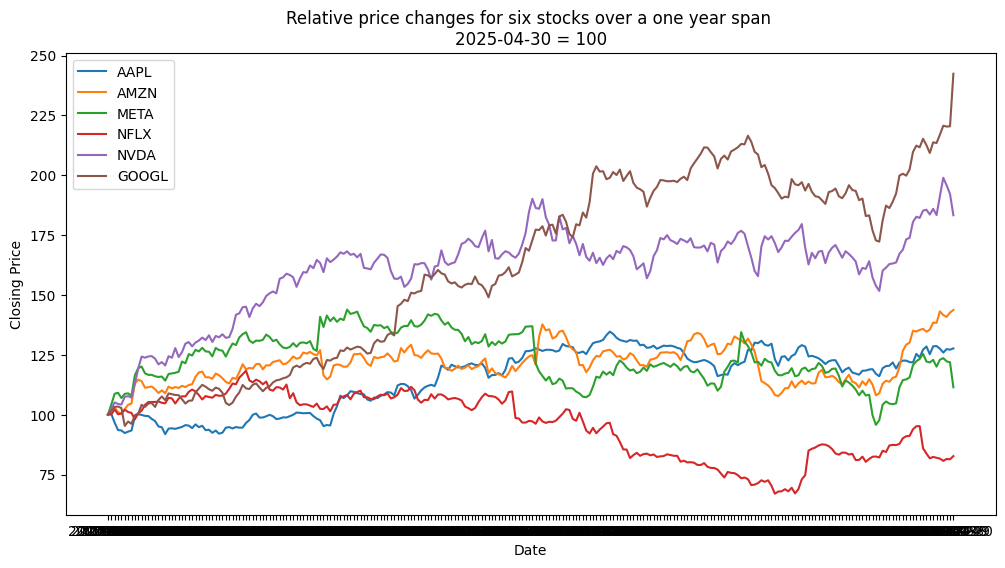

In [128]:
import matplotlib.pyplot as plt


daily_aapl_one_yr_resc = df_one_yr_resc[df_one_yr_resc['ticker'] == 'AAPL']
daily_amzn_one_yr_resc = df_one_yr_resc[df_one_yr_resc['ticker'] == 'AMZN']
daily_meta_one_yr_resc = df_one_yr_resc[df_one_yr_resc['ticker'] == 'META']
daily_nflx_one_yr_resc = df_one_yr_resc[df_one_yr_resc['ticker'] == 'NFLX']
daily_nvda_one_yr_resc = df_one_yr_resc[df_one_yr_resc['ticker'] == 'NVDA']
daily_googl_one_yr_resc = df_one_yr_resc[df_one_yr_resc['ticker'] == 'GOOGL']

# # Make sure timestamps are datetime
# for df in [daily_aapl, daily_nvda, daily_amzn, daily_googl]:
#     df['timestamp'] = pd.to_datetime(df['timestamp'])
#     df.sort_values('timestamp', inplace=True)

# Plot
plt.figure(figsize=(12,6))

plt.plot(daily_aapl_one_yr_resc['timestamp'], daily_aapl_one_yr_resc['close_pct_of_day1'], label='AAPL')
plt.plot(daily_amzn_one_yr_resc['timestamp'], daily_amzn_one_yr_resc['close_pct_of_day1'], label='AMZN')
plt.plot(daily_meta_one_yr_resc['timestamp'], daily_meta_one_yr_resc['close_pct_of_day1'], label='META')
plt.plot(daily_nflx_one_yr_resc['timestamp'], daily_nflx_one_yr_resc['close_pct_of_day1'], label='NFLX')
plt.plot(daily_nvda_one_yr_resc['timestamp'], daily_nvda_one_yr_resc['close_pct_of_day1'], label='NVDA')
plt.plot(daily_googl_one_yr_resc['timestamp'], daily_googl_one_yr_resc['close_pct_of_day1'], label='GOOGL')


plt.xlabel('Date')
plt.ylabel('Closing Price')
#plt.xticks(rotation=45)
plt.title('Relative price changes for six stocks over a one year span \n2025-04-30 = 100')
plt.legend()

plt.show()

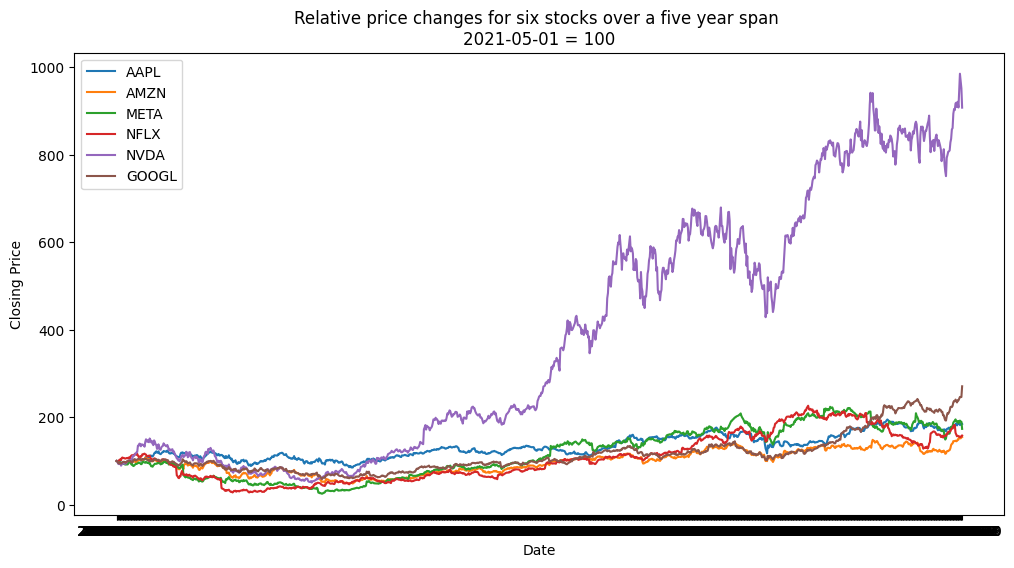

In [131]:
import matplotlib.pyplot as plt


daily_aapl_five_yr_resc = df_five_yr_resc[df_five_yr_resc['ticker'] == 'AAPL']
daily_amzn_five_yr_resc = df_five_yr_resc[df_five_yr_resc['ticker'] == 'AMZN']
daily_meta_five_yr_resc = df_five_yr_resc[df_five_yr_resc['ticker'] == 'META']
daily_nflx_five_yr_resc = df_five_yr_resc[df_five_yr_resc['ticker'] == 'NFLX']
daily_nvda_five_yr_resc = df_five_yr_resc[df_five_yr_resc['ticker'] == 'NVDA']
daily_googl_five_yr_resc = df_five_yr_resc[df_five_yr_resc['ticker'] == 'GOOGL']

# # Make sure timestamps are datetime
# for df in [daily_aapl, daily_nvda, daily_amzn, daily_googl]:
#     df['timestamp'] = pd.to_datetime(df['timestamp'])
#     df.sort_values('timestamp', inplace=True)

# Plot
plt.figure(figsize=(12,6))

plt.plot(daily_aapl_five_yr_resc['timestamp'], daily_aapl_five_yr_resc['close_pct_of_day1'], label='AAPL')
plt.plot(daily_amzn_five_yr_resc['timestamp'], daily_amzn_five_yr_resc['close_pct_of_day1'], label='AMZN')
plt.plot(daily_meta_five_yr_resc['timestamp'], daily_meta_five_yr_resc['close_pct_of_day1'], label='META')
plt.plot(daily_nflx_five_yr_resc['timestamp'], daily_nflx_five_yr_resc['close_pct_of_day1'], label='NFLX')
plt.plot(daily_nvda_five_yr_resc['timestamp'], daily_nvda_five_yr_resc['close_pct_of_day1'], label='NVDA')
plt.plot(daily_googl_five_yr_resc['timestamp'], daily_googl_five_yr_resc['close_pct_of_day1'], label='GOOGL')


plt.xlabel('Date')
plt.ylabel('Closing Price')
#plt.xticks(rotation=45)
plt.title('Relative price changes for six stocks over a five year span \n2021-05-01 = 100')
plt.legend()

plt.show()

# 10. Create another table for the same five stocks showing the probability that the next day
is positive after:
● 2 consecutive positive days
● 3 consecutive positive days
● 4 consecutive positive days
● 5 consecutive positive days
● 6 consecutive positive days

In [81]:
#ticker_list = df_daily_five_years['ticker'].unique().tolist()
ticker_list = ['AAPL', 'NVDA', 'NFLX', 'AMZN', 'GOOGL', 'META']

#thresholds = -1, -2, -3, -4, -5, -6, -10, -15, -20
streak_lengths = 2, 3, 4, 5, 6, 7

print("Span: 5 years")

Span: 5 years


In [ ]:
for ticker in ticker_list
    ticker_df = df_daily_five_years[df_daily_five_years['ticker'] == ticker]
    
    for streak in streak_lengths
        

In [80]:
# Condition: value > 10
condition = df_daily_one_year['pct_change_from_prev'] > 0

# 1. Group by ticker, and create an ID for consecutive rows that change condition
consecutive_id = condition.ne(condition.shift()).groupby(df_daily_one_year['ticker']).cumsum()

# 2. Group by both the ticker and the consecutive_id
result = df_daily_one_year[condition].groupby(['ticker', consecutive_id])

# Example: Get the size (consecutive count) for each streak
print(result.size())

ticker  pct_change_from_prev
A       1                       1
        3                       1
        5                       2
        7                       1
        9                       2
                               ..
ZYME    116                     3
        118                     4
        120                     2
        122                     4
        124                     2
Length: 182061, dtype: int64


In [83]:
safe_df.columns

Index(['timestamp', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'vwap',
       'transactions', 'SMA10', 'SMA20', 'SMA50', 'SMA100',
       'pct_change_from_prev', 'next_close_pct_change'],
      dtype='object')

In [82]:
safe_df = df_daily_five_years.copy()

In [ ]:
# Create a group that increments every time we hit an active day
grp = (
    full_equity_df['active_day']
    .eq(1)
    .groupby(full_equity_df['user_id'])
    .cumsum()
)

# Count days since last active day
full_equity_df['days_since_last_active'] = (
    full_equity_df
    .groupby(['user_id', grp])
    .cumcount()
)

In [ ]:
# 1. Identify rows meeting the condition
df['is_pos'] = df['val'] > 0

# 2. Create unique IDs for each block of consecutive values
# Every time 'is_pos' changes, a new group starts
df['group'] = (df['is_pos'] != df['is_pos'].shift()).cumsum()

# 3. Calculate running streak within each group
# We use cumsum on 'is_pos' to count 1s, then reset non-positive streaks to 0
df['streak'] = df.groupby('group')['is_pos'].cumsum()
df.loc[~df['is_pos'], 'streak'] = 0


# 11. Repeat the same analysis for consecutive negative days.

# 12. Screen all Nasdaq and NYSE stocks and identify the top 10 trending stocks, ranked
by daily percentage change.

Until instructed otherwise, I will take this to mean percentage change over a single day. I will take the most recent day in my dataset.

Next question asks for a market_cap filter. Did not include that endpoint in my original dataset. I will take every stock for which there are no missing days in the entire five years, and download data for the last seven trading days. I'll print a list of the top 10 for a seven day trading span, and a one day span.

Should I redownload the entire dataset to include the market_cap endpoint? If so will have to rerun everything above. Might as well also include - name, exchange, country, some others.

# 13. Repeat the screening, but only include stocks with a market capitalization of $5 billion
or more.

# OLD

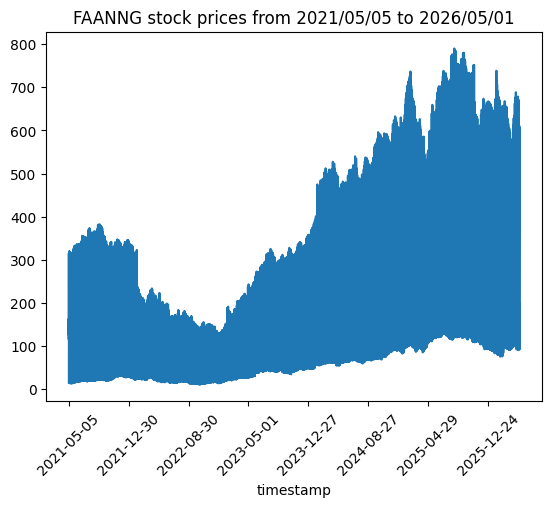

In [61]:
# Don't even remember where i made df_faaang
df_faanng.set_index('timestamp')['close'].plot()
plt.xticks(rotation=45)
# This title will have to be changed if SMA and next_close stats result in rows being dropped
plt.title('FAANNG stock prices from 2021/05/05 to 2026/05/01')
plt.show()